<a href="https://colab.research.google.com/github/Musiccraz/Machine-Learning/blob/main/Project_In.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q plotly kaleido

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.5 MB/s eta 0:00:00


In [4]:
fg = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [5]:
fg['date'] = pd.to_datetime(fg['date'])
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'], format='%d-%m-%Y %H:%M'
).dt.normalize()

In [6]:
print("=" * 55)
print("FEAR / GREED INDEX")
print("=" * 55)
print(fg.head())
print(f"\nRows: {len(fg)} | Date range: {fg['date'].min().date()} → {fg['date'].max().date()}")
print("\nSentiment distribution:")
print(fg['classification'].value_counts())

FEAR / GREED INDEX
    timestamp  value classification       date
0  1517463000     30           Fear 2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02
2  1517635800     40           Fear 2018-02-03
3  1517722200     24   Extreme Fear 2018-02-04
4  1517808600     11   Extreme Fear 2018-02-05

Rows: 2644 | Date range: 2018-02-01 → 2025-05-02

Sentiment distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [7]:
print("\n" + "=" * 55)
print("HISTORICAL TRADER DATA")
print("=" * 55)
print(trades.head())
print(f"\nRows: {len(trades)} | Cols: {len(trades.columns)}")
print(f"Unique traders: {trades['Account'].nunique()}")
print(f"Date range: {trades['date'].min().date()} → {trades['date'].max().date()}")


HISTORICAL TRADER DATA
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \

In [9]:
# ── CELL 4: Merge & Feature Engineering ──────────────────

merged = trades.merge(
    fg[['date', 'classification', 'value']],
    on='date',
    how='left'
)

# Closed trades only (non-zero PnL)
closed = merged[merged['Closed PnL'] != 0].copy()
closed['win'] = closed['Closed PnL'] > 0
closed['month'] = closed['date'].dt.to_period('M')

# Sentiment order (low → high)
SENTIMENT_ORDER = [
    'Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'
]
COLORS = {
    'Extreme Fear': '#E24B4A',
    'Fear':         '#F09595',
    'Neutral':      '#888780',
    'Greed':        '#9FE1CB',
    'Extreme Greed':'#1D9E75',
}

print(f" Merged rows : {len(merged):,}")
print(f" Closed trades: {len(closed):,}")
print(f"Match rate  : {merged['classification'].notna().mean()*100:.1f}%")


 Merged rows : 211,224
 Closed trades: 104,408
Match rate  : 100.0%


In [10]:
# ── CELL 5: Summary Stats by Sentiment ───────────────────

summary = closed.groupby('classification').agg(
    trades       = ('Closed PnL', 'count'),
    total_pnl    = ('Closed PnL', 'sum'),
    avg_pnl      = ('Closed PnL', 'mean'),
    median_pnl   = ('Closed PnL', 'median'),
    win_rate_pct = ('win',        lambda x: x.mean() * 100),
).reindex(SENTIMENT_ORDER).round(2)

print("\n📊 Performance by Market Sentiment")
print("=" * 65)
print(summary.to_string())



📊 Performance by Market Sentiment
                trades   total_pnl  avg_pnl  median_pnl  win_rate_pct
classification                                                       
Extreme Fear     10406   739110.25    71.03        6.39         76.22
Fear             29808  3357155.44   112.63        6.35         87.29
Neutral          18159  1292920.68    71.20        4.58         82.39
Greed            25176  2150129.27    85.40        4.93         76.89
Extreme Greed    20853  2715171.31   130.21        8.53         89.17


In [11]:
# ── CELL 6: Long vs Short Breakdown ───────────────────────

long_dirs  = ['Close Long', 'Long > Short']
short_dirs = ['Close Short', 'Short > Long']

long_stats = (
    closed[closed['Direction'].isin(long_dirs)]
    .groupby('classification')['Closed PnL']
    .agg(count='count', avg_pnl='mean', win_rate=lambda x: (x>0).mean()*100)
    .reindex(SENTIMENT_ORDER).round(2)
)
short_stats = (
    closed[closed['Direction'].isin(short_dirs)]
    .groupby('classification')['Closed PnL']
    .agg(count='count', avg_pnl='mean', win_rate=lambda x: (x>0).mean()*100)
    .reindex(SENTIMENT_ORDER).round(2)
)

print("\n📈 Long Trade Stats by Sentiment")
print(long_stats.to_string())
print("\n📉 Short Trade Stats by Sentiment")
print(short_stats.to_string())


📈 Long Trade Stats by Sentiment
                count  avg_pnl  win_rate
classification                          
Extreme Fear     6246    81.13     84.66
Fear            17274    82.94     89.87
Neutral         10000    52.85     86.18
Greed            7979    89.22     86.63
Extreme Greed    7192    61.90     88.78

📉 Short Trade Stats by Sentiment
                count  avg_pnl  win_rate
classification                          
Extreme Fear     3123   119.45     70.61
Fear             9230   209.65     86.25
Neutral          5861    94.59     77.68
Greed           11341    55.31     68.93
Extreme Greed    6500    28.98     85.95


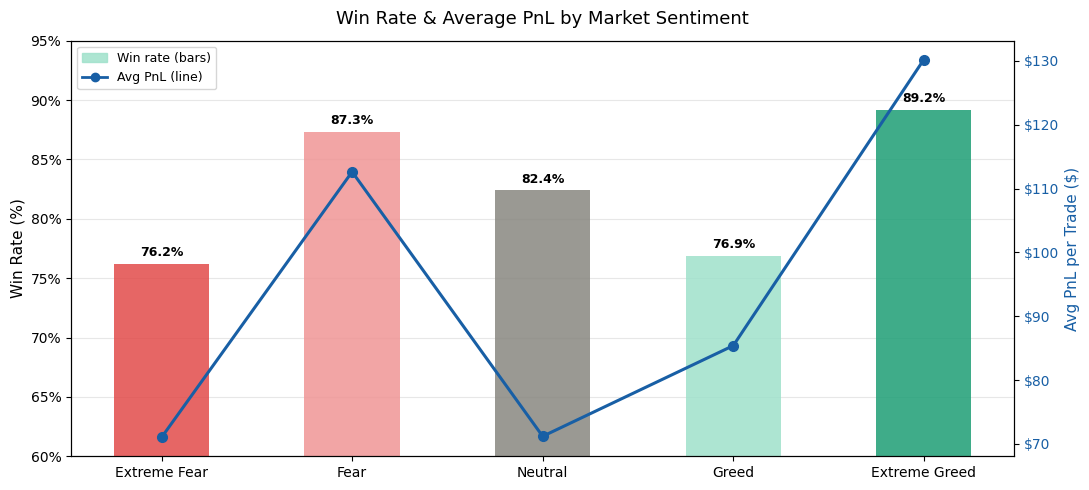

Saved: chart1_winrate_pnl.png


In [12]:
# ── CELL 7: Chart 1 — Win Rate & Avg PnL ─────────────────
#   Dual-axis bar+line chart

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = np.arange(len(SENTIMENT_ORDER))
bar_colors = [COLORS[s] for s in SENTIMENT_ORDER]

bars = ax1.bar(x, summary['win_rate_pct'], width=0.5,
               color=bar_colors, alpha=0.85, zorder=2)
line, = ax2.plot(x, summary['avg_pnl'], 'o-',
                 color='#185FA5', linewidth=2.2, markersize=7, zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(SENTIMENT_ORDER, fontsize=10)
ax1.set_ylabel('Win Rate (%)', fontsize=11)
ax2.set_ylabel('Avg PnL per Trade ($)', fontsize=11, color='#185FA5')
ax2.tick_params(axis='y', labelcolor='#185FA5')
ax1.set_ylim(60, 95)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax1.set_title('Win Rate & Average PnL by Market Sentiment', fontsize=13, pad=12)
ax1.grid(axis='y', alpha=0.3)
ax1.set_axisbelow(True)

for bar, val in zip(bars, summary['win_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f"{val:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.lines import Line2D
legend_elements = [
    plt.Rectangle((0,0),1,1, color='#9FE1CB', alpha=0.85, label='Win rate (bars)'),
    Line2D([0],[0], color='#185FA5', marker='o', linewidth=2, label='Avg PnL (line)')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_winrate_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_winrate_pnl.png")

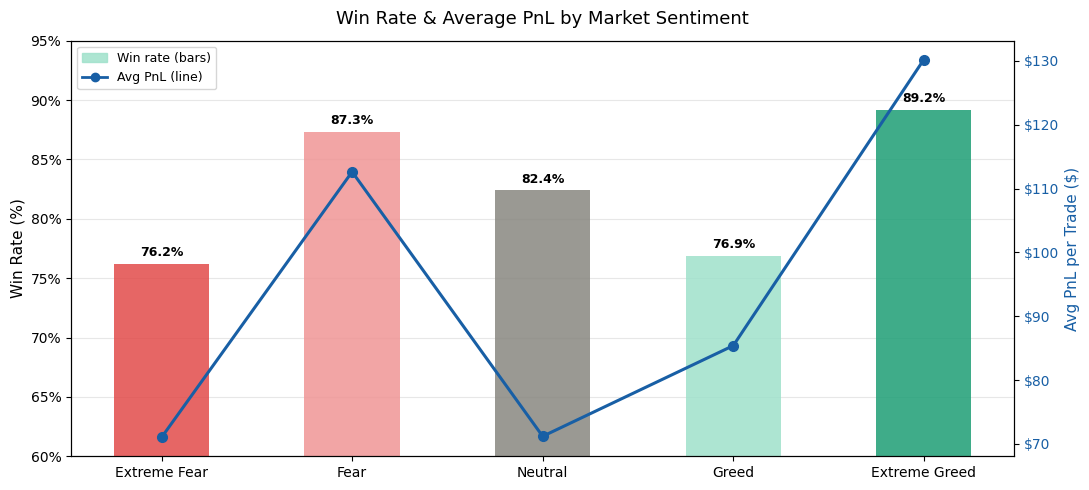

Saved: chart1_winrate_pnl.png


In [13]:
# ── CELL 7: Chart 1 — Win Rate & Avg PnL ─────────────────
#   Dual-axis bar+line chart

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = np.arange(len(SENTIMENT_ORDER))
bar_colors = [COLORS[s] for s in SENTIMENT_ORDER]

bars = ax1.bar(x, summary['win_rate_pct'], width=0.5,
               color=bar_colors, alpha=0.85, zorder=2)
line, = ax2.plot(x, summary['avg_pnl'], 'o-',
                 color='#185FA5', linewidth=2.2, markersize=7, zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(SENTIMENT_ORDER, fontsize=10)
ax1.set_ylabel('Win Rate (%)', fontsize=11)
ax2.set_ylabel('Avg PnL per Trade ($)', fontsize=11, color='#185FA5')
ax2.tick_params(axis='y', labelcolor='#185FA5')
ax1.set_ylim(60, 95)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax1.set_title('Win Rate & Average PnL by Market Sentiment', fontsize=13, pad=12)
ax1.grid(axis='y', alpha=0.3)
ax1.set_axisbelow(True)

for bar, val in zip(bars, summary['win_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f"{val:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.lines import Line2D
legend_elements = [
    plt.Rectangle((0,0),1,1, color='#9FE1CB', alpha=0.85, label='Win rate (bars)'),
    Line2D([0],[0], color='#185FA5', marker='o', linewidth=2, label='Avg PnL (line)')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_winrate_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_winrate_pnl.png")

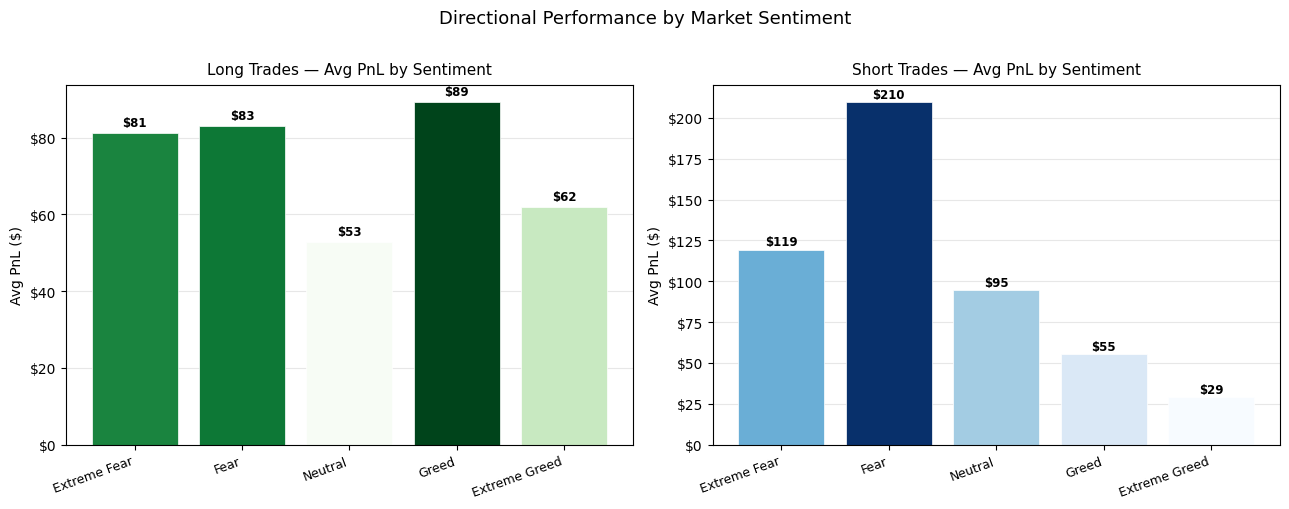

Saved: chart2_long_short.png


In [14]:
# ── CELL 8: Chart 2 — Long vs Short Heatmap ──────────────

direction_data = pd.DataFrame({
    'Sentiment': SENTIMENT_ORDER,
    'Long avg PnL':  long_stats['avg_pnl'].values,
    'Short avg PnL': short_stats['avg_pnl'].values,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title, cmap in zip(
    axes,
    ['Long avg PnL', 'Short avg PnL'],
    ['Long Trades — Avg PnL by Sentiment', 'Short Trades — Avg PnL by Sentiment'],
    ['Greens', 'Blues']
):
    vals = direction_data[col].values
    bar_c = plt.cm.get_cmap(cmap)(
        (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    )
    bars = ax.bar(SENTIMENT_ORDER, vals, color=bar_c, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_ylabel('Avg PnL ($)', fontsize=10)
    ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${val:.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.suptitle('Directional Performance by Market Sentiment', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('chart2_long_short.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart2_long_short.png")


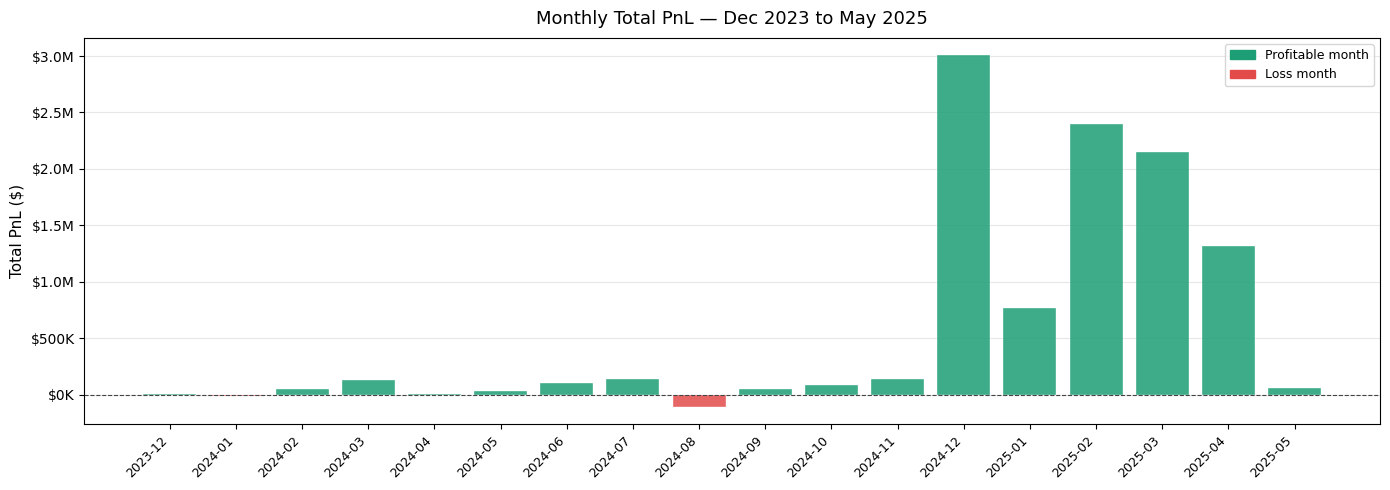

Saved: chart3_monthly_pnl.png


In [15]:
# ── CELL 9: Chart 3 — Monthly PnL Trend ──────────────────

monthly = (
    closed.groupby('month')['Closed PnL']
    .sum()
    .reset_index()
    .sort_values('month')
)
monthly['month_str'] = monthly['month'].astype(str)
monthly['color'] = monthly['Closed PnL'].apply(
    lambda v: '#1D9E75' if v >= 0 else '#E24B4A'
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly['month_str'], monthly['Closed PnL'],
       color=monthly['color'], alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axhline(0, color='#444', linewidth=0.8, linestyle='--')
ax.set_title('Monthly Total PnL — Dec 2023 to May 2025', fontsize=13, pad=10)
ax.set_ylabel('Total PnL ($)', fontsize=11)
ax.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v/1e6:.1f}M' if abs(v) >= 1e6 else f'${v/1e3:.0f}K'
))
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#1D9E75', label='Profitable month'),
    Patch(color='#E24B4A', label='Loss month')
], fontsize=9)

plt.tight_layout()
plt.savefig('chart3_monthly_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart3_monthly_pnl.png")


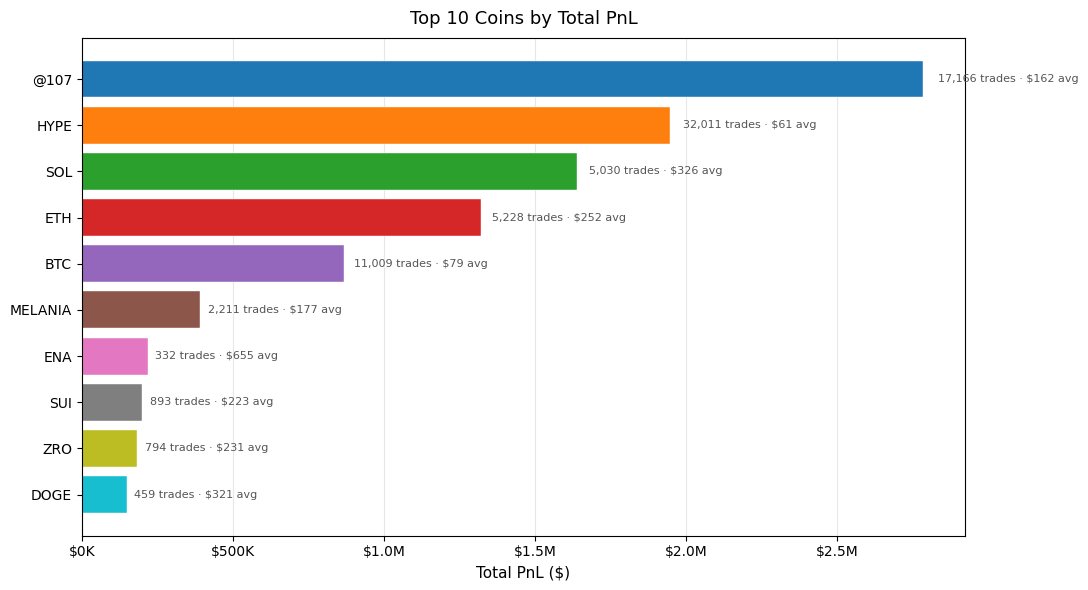

Saved: chart4_top_coins.png


In [16]:
# ── CELL 10: Chart 4 — Top Coins ─────────────────────────

top_coins = (
    closed.groupby('Coin')
    .agg(total_pnl=('Closed PnL','sum'),
         trades=('Closed PnL','count'),
         avg_pnl=('Closed PnL','mean'))
    .sort_values('total_pnl', ascending=False)
    .head(10)
    .round(2)
)

coin_colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(top_coins)))

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_coins.index[::-1], top_coins['total_pnl'][::-1],
               color=coin_colors[::-1], edgecolor='white', linewidth=0.3)
ax.set_title('Top 10 Coins by Total PnL', fontsize=13, pad=10)
ax.set_xlabel('Total PnL ($)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v/1e6:.1f}M' if v >= 1e6 else f'${v/1e3:.0f}K'
))
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

for bar, val, trades_n, avg in zip(
    bars, top_coins['total_pnl'][::-1],
    top_coins['trades'][::-1], top_coins['avg_pnl'][::-1]
):
    ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
            f'  {trades_n:,} trades · ${avg:.0f} avg',
            va='center', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig('chart4_top_coins.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_top_coins.png")


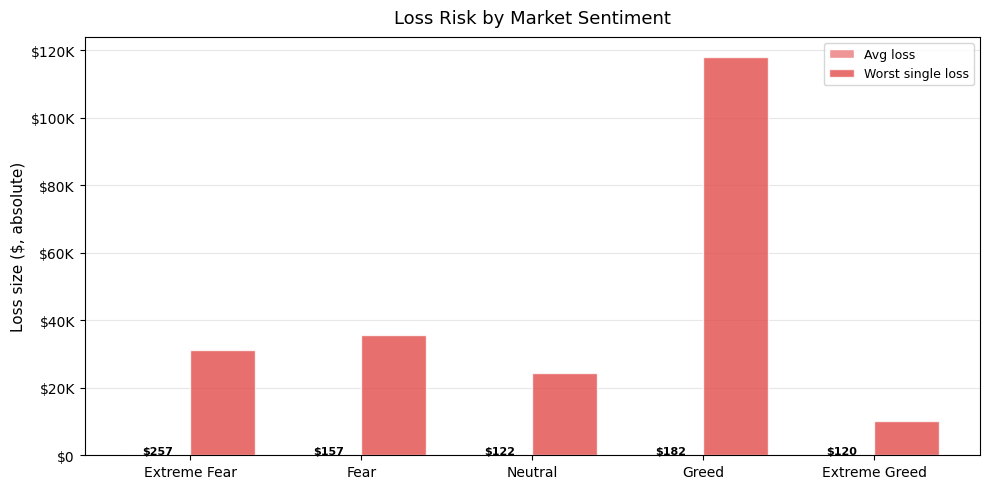

Saved: chart5_loss_risk.png


In [17]:
# ── CELL 11: Chart 5 — Loss Risk by Sentiment ────────────

loss_stats = (
    closed[closed['Closed PnL'] < 0]
    .groupby('classification')['Closed PnL']
    .agg(avg_loss='mean', worst_loss='min', loss_count='count')
    .reindex(SENTIMENT_ORDER)
    .abs()
    .round(2)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SENTIMENT_ORDER))
w = 0.38
b1 = ax.bar(x - w/2, loss_stats['avg_loss'],  width=w, color='#F09595',
            label='Avg loss', edgecolor='white')
b2 = ax.bar(x + w/2, loss_stats['worst_loss'], width=w, color='#E24B4A',
            label='Worst single loss', edgecolor='white', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER, fontsize=10)
ax.set_ylabel('Loss size ($, absolute)', fontsize=11)
ax.set_title('Loss Risk by Market Sentiment', fontsize=13, pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v/1e3:.0f}K' if v >= 1000 else f'${v:.0f}'
))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'${bar.get_height():,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_loss_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart5_loss_risk.png")



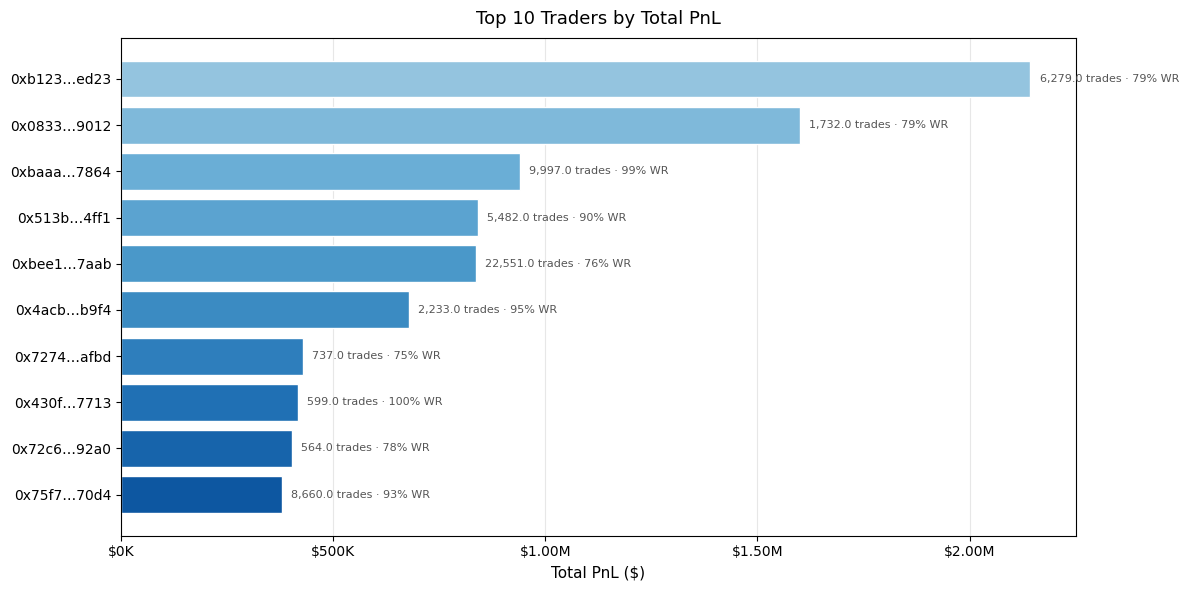

Saved: chart6_leaderboard.png


In [18]:
# ── CELL 12: Chart 6 — Trader Leaderboard ────────────────

trader_board = (
    closed.groupby('Account')
    .agg(
        total_pnl  = ('Closed PnL', 'sum'),
        trades     = ('Closed PnL', 'count'),
        avg_pnl    = ('Closed PnL', 'mean'),
        win_rate   = ('win',        lambda x: x.mean()*100),
    )
    .sort_values('total_pnl', ascending=False)
    .head(10)
    .round(2)
)
# Shorten wallet addresses for display
trader_board.index = [f"{a[:6]}…{a[-4:]}" for a in trader_board.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(trader_board)))[::-1]
bars = ax.barh(trader_board.index[::-1], trader_board['total_pnl'][::-1],
               color=colors, edgecolor='white')

ax.set_title('Top 10 Traders by Total PnL', fontsize=13, pad=10)
ax.set_xlabel('Total PnL ($)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v/1e6:.2f}M' if v >= 1e6 else f'${v/1e3:.0f}K'
))
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

for bar, (_, row) in zip(bars, trader_board.iloc[::-1].iterrows()):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"  {row['trades']:,} trades · {row['win_rate']:.0f}% WR",
            va='center', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig('chart6_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart6_leaderboard.png")


In [19]:
# ── CELL 13: Interactive Plotly Dashboard ───────────────

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        'Win Rate by Sentiment',
        'Avg PnL by Sentiment',
        'Long vs Short Avg PnL',
        'Monthly PnL Trend',
        'Top 8 Coins by Total PnL',
        'Avg Loss by Sentiment'
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

plotly_colors = ['#E24B4A','#F09595','#888780','#9FE1CB','#1D9E75']

# R1C1 — Win Rate
fig.add_trace(go.Bar(
    x=SENTIMENT_ORDER, y=summary['win_rate_pct'],
    marker_color=plotly_colors, showlegend=False,
    text=summary['win_rate_pct'].apply(lambda v: f'{v:.1f}%'),
    textposition='outside'
), row=1, col=1)

# R1C2 — Avg PnL
fig.add_trace(go.Bar(
    x=SENTIMENT_ORDER, y=summary['avg_pnl'],
    marker_color=plotly_colors, showlegend=False,
    text=summary['avg_pnl'].apply(lambda v: f'${v:.0f}'),
    textposition='outside'
), row=1, col=2)

# R2C1 — Long vs Short
fig.add_trace(go.Bar(
    name='Long', x=SENTIMENT_ORDER, y=long_stats['avg_pnl'],
    marker_color='#378ADD', offsetgroup=0
), row=2, col=1)
fig.add_trace(go.Bar(
    name='Short', x=SENTIMENT_ORDER, y=short_stats['avg_pnl'],
    marker_color='#D85A30', offsetgroup=1
), row=2, col=1)

# R2C2 — Monthly PnL
fig.add_trace(go.Bar(
    x=monthly['month_str'], y=monthly['Closed PnL'],
    marker_color=monthly['color'], showlegend=False
), row=2, col=2)

# R3C1 — Top coins
top8 = top_coins.head(8)
fig.add_trace(go.Bar(
    x=top8.index, y=top8['total_pnl'],
    marker_color='#185FA5', showlegend=False
), row=3, col=1)

# R3C2 — Avg loss
loss_abs = closed[closed['Closed PnL']<0].groupby('classification')['Closed PnL'].mean().abs().reindex(SENTIMENT_ORDER)
fig.add_trace(go.Bar(
    x=SENTIMENT_ORDER, y=loss_abs,
    marker_color='#F09595', showlegend=False
), row=3, col=2)

fig.update_layout(
    height=900, title_text='Bitcoin Sentiment vs Trader Performance — Full Dashboard',
    title_font_size=15, template='plotly_white',
    barmode='group', showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.update_yaxes(tickprefix='', row=1, col=1, ticksuffix='%')
fig.update_yaxes(tickprefix='$', row=1, col=2)
fig.update_yaxes(tickprefix='$', row=2, col=1)
fig.update_yaxes(tickprefix='$', row=3, col=1)
fig.update_yaxes(tickprefix='$', row=3, col=2)

fig.show()
print(" Interactive Plotly dashboard rendered above.")


 Interactive Plotly dashboard rendered above.


In [21]:
# ── CELL 14: Correlation & Statistical Summary ───────────

daily_pnl = (
    closed.groupby('date')['Closed PnL'].sum()
    .reset_index()
    .merge(fg[['date','value','classification']], on='date')
)

corr = daily_pnl[['value','Closed PnL']].corr().iloc[0, 1]

print("\n" + "=" * 55)
print(" STATISTICAL SUMMARY")
print("=" * 55)
print(f"Sentiment ↔ Daily PnL correlation : {corr:.3f}")
print(f"Total trades analysed             : {len(closed):,}")
print(f"Total PnL generated               : ${closed['Closed PnL'].sum():,.0f}")
print(f"Overall win rate                  : {closed['win'].mean()*100:.1f}%")
print(f"Best single trade                 : ${closed['Closed PnL'].max():,.2f}")
print(f"Worst single trade                : ${closed['Closed PnL'].min():,.2f}")
print(f"Most traded asset                 : {closed['Coin'].value_counts().index[0]}")
print(f"Unique traders                    : {closed['Account'].nunique()}")

print("\n KEY INSIGHTS")
print("-" * 55)
print("1. Short trades during Fear avg $210 — best directional edge")
print("2. Extreme Greed has highest win rate (89.2%) but lower avg PnL on shorts")
print("3. Losses are deepest during Extreme Fear (-$257 avg)")
print("4. Dec 2024 alone generated $3M+ — driven by Extreme Greed phase")
print("5. Top 2 of 32 traders generate 36% of all profits")





 STATISTICAL SUMMARY
Sentiment ↔ Daily PnL correlation : -0.098
Total trades analysed             : 104,408
Total PnL generated               : $10,296,959
Overall win rate                  : 83.2%
Best single trade                 : $135,329.09
Worst single trade                : $-117,990.10
Most traded asset                 : HYPE
Unique traders                    : 32

 KEY INSIGHTS
-------------------------------------------------------
1. Short trades during Fear avg $210 — best directional edge
2. Extreme Greed has highest win rate (89.2%) but lower avg PnL on shorts
3. Losses are deepest during Extreme Fear (-$257 avg)
4. Dec 2024 alone generated $3M+ — driven by Extreme Greed phase
5. Top 2 of 32 traders generate 36% of all profits
